# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 9 — Statistics of fatigue, S–N fitting, Weibull, POD

- [Exercise 9.1](#ex1) — Sources and characteristics of fatigue scatter
- [Exercise 9.2](#ex2) — S–N data fitting: brass
- [Exercise 9.3](#ex3) — S–N data fitting: steel with fatigue limit
- [Exercise 9.4](#ex4) — Weibull distribution and POD concepts


In [1]:
import numpy as np
import matplotlib.pyplot as plt
FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085')


<a id='ex1'></a>
---

## 9.1 — Sources and characteristics of fatigue scatter

(a) List the main sources of scatter in fatigue test results.

(b) Compare the scatter typically observed in: (i) the crack initiation period and (ii) the crack growth period. In which period is scatter usually larger?

(c) Is the scatter of the fatigue limit larger or smaller than the scatter of fatigue lives at high stress amplitudes? Why?

(d) At a given stress amplitude, should the statistical distribution of fatigue lives be described by a Gaussian (normal), log-normal, or Weibull distribution? Justify.

(e) What is the practical meaning of a $p$–S–N curve? How is it constructed?

(f) How many specimens are needed to determine the fatigue limit with reasonable statistical confidence? Which test strategies exist (staircase method, etc.)?

### Solution

**(a) Main sources.**

| Source | Effect |
|---|---|
| Microstructural heterogeneity (inclusions, grain size) | $1\times$ to $10\times$ scatter in initiation life |
| Surface condition (roughness, residual stress) | dominant for HCF |
| Specimen geometry/alignment | larger scatter in axial than rotating bending |
| Loading machine (frequency, waveform precision) | typically negligible if machine is in spec |
| Environment (humidity, temperature) | systematic shift + scatter |
| Statistical sampling (small N) | unavoidable for HCF |

**(b) Initiation vs. growth scatter.**

Scatter is **much larger** in the **initiation** period. The reason: initiation
depends on the size and position of a critical defect, which has a wide
*statistical* distribution; once a crack exists, the growth law
$\mathrm{d}a/\mathrm{d}N=C(\Delta K)^{m}$ describes a deterministic process
(scatter $<2\times$ typically).

**(c) Scatter of the fatigue limit.**

**Larger** than the finite-life scatter, because the fatigue limit sits in
the "all-or-nothing" transition region of the S–N curve. A small change in
amplitude moves a specimen from "survives" to "fails", so the *measured*
$\sigma_f$ has a high coefficient of variation (∼5–15 %) compared to ∼1–2 %
for $\sigma_a$ at a given $N_f$ in the finite-life branch.

**(d) Distribution of $N_f$ at fixed $\sigma_a$.**

Empirically **log-normal** is the most common choice for $N_f$ in HCF.
Reasons: the central-limit argument on the *log* of life (initiation + growth
+ propagation combine multiplicatively), and the long upper tail observed
experimentally. **Weibull** is the second most common, used when one wants a
finite minimum life ($\beta>1$). Gaussian on $N_f$ (untransformed) is rarely
appropriate because it allows negative values.

**(e) $p$–S–N curve.** A family of S–N curves, each corresponding to a
survival probability $p$ (10 %, 50 %, 90 % …). Constructed by fitting a
log-normal (or Weibull) distribution at *each* stress amplitude, then
plotting the $p$-percentile of $N_f$ vs. $\sigma_a$.

**(f) Sample size and test strategies.**

For fatigue *limit* with $\pm 5$ % precision: ~30 specimens at amplitudes
straddling $\sigma_f$. Practical methods:

* **Staircase (Dixon–Mood)** — alternating runs above/below the failure
  threshold; very sample-efficient.
* **Probit method** — fixed amplitudes, count failures and survivors.
* **Up-and-down with replacement** — variant of staircase.

For the *finite-life* S–N curve: typically 5–6 amplitudes × 3–5 specimens each.


<a id='ex2'></a>
---

## 9.2 — S–N data fitting: brass

Rotating-bending fatigue tests on a brass alloy yielded the following results:

| $\sigma_a$ (MPa) | $N_f$ (cycles) |
| --- | --- |
| 170 | $3.7\times10^4$ |
| 148 | $1.0\times10^5$ |
| 130 | $3.0\times10^5$ |
| 114 | $1.0\times10^6$ |
| 92 | $1.0\times10^7$ |
| 80 | $1.0\times10^8$ |
| 74 | $1.0\times10^9$ |

(a) Plot the S–N data on a log–log scale.

(b) Fit a power-law curve $\sigma_a = AN_f^b$ using log–log regression. Report $A$, $b$ and $R^2$.

(c) Does this material exhibit a clear fatigue limit? Compare with the behaviour of a typical steel (BCC vs. FCC crystal structure).

(d) Use the fitted curve to estimate: (i) $N_f$ for $\sigma_a = 120$ MPa, and (ii) $\sigma_a$ for $N_f = 4\times10^6$.

### Solution



In [ ]:
sigma_a = np.array([170, 148, 130, 114, 92, 80, 74], dtype=float)
N_f     = np.array([3.7e4, 1e5, 3e5, 1e6, 1e7, 1e8, 1e9])

# Log-log linear fit
slope, intercept = np.polyfit(np.log10(N_f), np.log10(sigma_a), 1)
b_fit = slope
A_fit = 10**intercept
R2 = 1 - np.sum((np.log10(sigma_a) - (intercept + slope*np.log10(N_f)))**2) \
       /np.sum((np.log10(sigma_a) - np.log10(sigma_a).mean())**2)
print(f'Fit: σ_a = A · N_f^b   with')
print(f'    A  = {A_fit:.2f} MPa')
print(f'    b  = {b_fit:.4f}  →  m_SN = -1/b = {-1/b_fit:.2f}')
print(f'    R² = {R2:.5f}')

fig, ax = plt.subplots()
ax.loglog(N_f, sigma_a, 'o', markersize=10, color=COLORS['curve'], label='data')
N_plot = np.logspace(3.5, 9.5, 100)
ax.loglog(N_plot, A_fit*N_plot**b_fit, '-', color=COLORS['point'], lw=2,
          label=fr'fit: $\sigma_a = {A_fit:.1f}\,N_f^{{{b_fit:.3f}}}$')
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_title('Exercise 9.2 — Brass S–N (rotating bending)')
ax.legend(); plt.tight_layout(); plt.show()

# (d) Predictions
sa_d1 = 120.0; Nf_d1 = (sa_d1/A_fit)**(1/b_fit)
Nf_d2 = 4e6;   sa_d2 = A_fit*Nf_d2**b_fit
print(f'\n(d) Predictions:')
print(f'    σ_a = {sa_d1} MPa  →  N_f ≈ {Nf_d1:.3e} cycles')
print(f'    N_f = {Nf_d2:.0e} cycles  →  σ_a ≈ {sa_d2:.2f} MPa')


**(c) Fatigue limit?**

Brass is FCC. FCC metals (Cu, Al, Ni alloys) **do not** show a clear horizontal
asymptote on the S–N curve — slip is easier, dislocation barriers are weaker,
and the curve keeps sloping down even at $N>10^{9}$ cycles. Steels (BCC at room
T) have a true fatigue limit at $\sim 10^{6}$–$10^{7}$ cycles thanks to
dislocation locking by interstitial atoms (Cottrell atmospheres). The brass
data above are consistent with this: even at $7.4\times 10^{8}$ cycles the
curve is still falling.


#### Solution summary — Exercise 9.2

| Quantity | Value |
|---|---:|
| Coefficient $A$ | 374.35 MPa |
| Exponent $b$ | −0.0823 |
| Slope $m_\text{SN} = -1/b$ | 12.16 |
| $R^2$ | 0.9614 |
| $N_f$ for $\sigma_a = 120$ MPa | $1.02 \times 10^6$ cycles |
| $\sigma_a$ for $N_f = 4\times10^6$ cycles | 107.2 MPa |

The steep effective S–N slope ($m_\text{SN}\approx 12$) and the continuously descending curve confirm the absence of a fatigue limit, consistent with the FCC crystal structure of brass.

<a id='ex3'></a>
---

## 9.3 — S–N data fitting: steel with fatigue limit

Rotating-bending fatigue tests on a steel alloy yielded:

| $\sigma_a$ (MPa) | $N_f$ (cycles) |
| --- | --- |
| 470 | $1\times10^4$ |
| 440 | $3\times10^4$ |
| 390 | $1\times10^5$ |
| 350 | $3\times10^5$ |
| 310 | $1\times10^6$ |
| 290 | $3\times10^6$ |
| 290 | $1\times10^7$ |
| 290 | $1\times10^8$ |

(a) Plot the S–N data. Identify the fatigue limit.

(b) Fit a power law to the finite-life region only (exclude the plateau points). Report $A$, $b$ and $R^2$.

(c) This steel is used in an automotive shaft rotating at 600 rpm. Compute the expected service life (in hours) for $\sigma_a = 380$ MPa.

(d) What is the maximum stress amplitude for the shaft to survive 1 year of continuous operation?

### Solution



In [ ]:
sigma_a = np.array([470,440,390,350,310,290,290,290], dtype=float)
N_f     = np.array([1e4, 3e4, 1e5, 3e5, 1e6, 3e6, 1e7, 1e8])

# (a) Identify fatigue limit (constant value at high N)
plateau_mask = (sigma_a == 290)
sigma_f = sigma_a[plateau_mask][0]
print(f'(a) Fatigue limit observed at σ_f = {sigma_f} MPa (plateau from N ~ 3·10⁶)')

# (b) Fit only finite-life region
mask = ~plateau_mask
slope, intercept = np.polyfit(np.log10(N_f[mask]), np.log10(sigma_a[mask]), 1)
b_fit = slope; A_fit = 10**intercept
R2 = 1 - np.sum((np.log10(sigma_a[mask]) - (intercept + slope*np.log10(N_f[mask])))**2) \
       /np.sum((np.log10(sigma_a[mask]) - np.log10(sigma_a[mask]).mean())**2)
print(f'(b) Finite-life fit: A = {A_fit:.2f} MPa,  b = {b_fit:.4f}  (m_SN = {-1/b_fit:.2f})')
print(f'    R² = {R2:.5f}')

fig, ax = plt.subplots()
ax.loglog(N_f[mask], sigma_a[mask], 'o', markersize=10, color=COLORS['curve'], label='finite life')
ax.loglog(N_f[plateau_mask], sigma_a[plateau_mask], 's', markersize=10,
          color=COLORS['point'], label=f'fatigue limit ({sigma_f} MPa)')
N_plot = np.logspace(3.5, 5.5, 100)
ax.loglog(N_plot, A_fit*N_plot**b_fit, '-', color=COLORS['cool'], lw=2,
          label=fr'fit: $\sigma_a = {A_fit:.0f}\,N_f^{{{b_fit:.3f}}}$')
ax.axhline(sigma_f, color=COLORS['point'], ls='--', lw=1.5)
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'$\sigma_a$ (MPa)')
ax.set_title('Exercise 9.3 — Steel S–N with fatigue limit at 290 MPa')
ax.legend(); plt.tight_layout(); plt.show()

# (c) σ_a = 380 MPa, shaft at 600 rpm → hours
sa = 380.0
Nf_380 = (sa/A_fit)**(1/b_fit)
hours = Nf_380/(600*60)
print(f'\n(c) σ_a = {sa} MPa → N_f ≈ {Nf_380:.3e} cycles')
print(f'    At 600 rpm: t = N_f/(600·60) ≈ {hours:.2f} hours ≈ {hours/24:.2f} days')

# (d) Max σ_a for 1 year service: N_target = 600 rpm · 60 · 24 · 365 cycles
N_target = 600*60*24*365
sa_max   = A_fit*N_target**b_fit
print(f'\n(d) 1 year of continuous operation → N_target = {N_target:.3e} cycles')
print(f'    Maximum σ_a = {sa_max:.2f} MPa')
print(f'    (This is below the fatigue limit {sigma_f} MPa, so the shaft also satisfies '
      f'the infinite-life criterion if σ_a ≤ {sigma_f} MPa.)')


#### Solution summary — Exercise 9.3

| Quantity | Value |
|---|---:|
| Fatigue limit $\sigma_f$ | 290 MPa (plateau from $N \approx 3\times10^6$) |
| Coefficient $A$ (finite-life) | 1118.91 MPa |
| Exponent $b$ | −0.0922 |
| Slope $m_\text{SN} = -1/b$ | 10.84 |
| $R^2$ (finite-life fit) | 0.9932 |
| $N_f$ for $\sigma_a = 380$ MPa | $1.21 \times 10^5$ cycles → **3.4 h** at 600 rpm |
| Max $\sigma_a$ for 1 year ($N = 3.15\times10^8$) | 184 MPa |

The 1-year maximum (184 MPa) is well below the fatigue limit (290 MPa), so the shaft satisfies the infinite-life criterion for any $\sigma_a \le 290$ MPa.

<a id='ex4'></a>
---

## 9.4 — Weibull distribution and POD concepts

(a) The two-parameter Weibull distribution is often used to model fatigue life scatter. Write its CDF and explain the meaning of the shape parameter $\beta$ and scale parameter $\eta$.

(b) Given 10 fatigue life results (in $10^3$ cycles): 45, 52, 58, 63, 71, 78, 89, 105, 132, 190, estimate the Weibull parameters using a linearised plot (Weibull probability paper).

(c) Define the Probability of Detection (POD) for an NDI technique. Why is the POD curve important for establishing inspection intervals in damage-tolerant design?

(d) Explain the concept of the $a_{90/95}$ crack size in the context of POD.

### Solution

#### (a) Two-parameter Weibull

\begin{equation*}
F(N) = 1 - \exp\!\left[-\left(\dfrac{N}{\eta}\right)^{\beta}\right],
\qquad N\ge 0.
\tag{9.4.1}\end{equation*}

* $\beta$ — **shape parameter**.
  $\beta=1$: exponential (constant hazard rate, "memoryless");
  $\beta>1$: increasing hazard (wear-out / fatigue), $\beta=3.5$ resembles a normal;
  $\beta<1$: decreasing hazard (infant mortality).
* $\eta$ — **scale parameter** (the 63.2 % failure life): $F(\eta)=1-e^{-1}\approx 0.632$.

#### (b) Fit to 10 fatigue lives


In [ ]:
# Data in units of 10^3 cycles
N_data = np.array([45, 52, 58, 63, 71, 78, 89, 105, 132, 190])*1e3
n = len(N_data)
N_sorted = np.sort(N_data)

# Median-rank estimator for empirical CDF (Bernard's approximation)
i = np.arange(1, n+1)
F = (i - 0.3)/(n + 0.4)

# Linearise: ln[ -ln(1-F) ] = β·ln(N) - β·ln(η)
y = np.log(-np.log(1-F))
x = np.log(N_sorted)
beta, neg_b_log_eta = np.polyfit(x, y, 1)
eta = np.exp(-neg_b_log_eta/beta)
print(f'Weibull fit:  β = {beta:.3f},  η = {eta:.0f} cycles  ({eta/1e3:.1f} ·10³)')

# Goodness of fit
R2 = 1 - np.sum((y - (beta*x + neg_b_log_eta))**2)/np.sum((y - y.mean())**2)
print(f'             R² = {R2:.5f}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(N_sorted/1e3, F, 'o', color=COLORS['curve'], markersize=9, label='median rank')
Nfit = np.linspace(N_sorted.min(), N_sorted.max(), 200)
Ffit = 1 - np.exp(-(Nfit/eta)**beta)
ax.plot(Nfit/1e3, Ffit, '-', color=COLORS['point'], lw=2,
        label=fr'fit: $F=1-\exp[-(N/{eta/1e3:.0f})^{{{beta:.2f}}}]$')
ax.set_xlabel(r'$N$ (10³ cycles)'); ax.set_ylabel(r'$F(N)$')
ax.set_title('Empirical CDF vs Weibull fit')
ax.legend()

ax = axes[1]
ax.plot(x, y, 'o', color=COLORS['curve'], markersize=9)
xfit = np.linspace(x.min(), x.max(), 100)
ax.plot(xfit, beta*xfit + neg_b_log_eta, '-', color=COLORS['point'], lw=2)
ax.set_xlabel(r'$\ln N$'); ax.set_ylabel(r'$\ln[-\ln(1-F)]$')
ax.set_title('Weibull probability paper (linearised)')
plt.tight_layout(); plt.show()


#### (c) Probability of Detection (POD)

The POD is the **probability that an NDI technique detects a defect of size
$a$**, given that the defect is present. Typical POD curves rise from ~0 at
$a\sim 0$ to ~1 at large $a$, with a transition region in between.

**Why POD matters for damage-tolerant design.**

Damage tolerance assumes the structure operates with a *largest credible
undetected* crack $a_{0,\text{NDI}}$. The inspection interval is set so
that this crack cannot grow to $a_c$ before the next inspection
(typically with a safety factor of 2 on life). $a_{0,\text{NDI}}$ is taken
from the POD curve, **not** the operator's expected detection limit.

#### (d) The $a_{90/95}$ crack size

$a_{90/95}$ is the crack size at which **90 % of the cracks are detected with
95 % statistical confidence** — i.e. the **lower 95 % confidence bound** on
the size that gives 90 % POD. It is the regulatory benchmark used in
aerospace damage-tolerance certification (FAA, EASA): the next inspection
interval is sized assuming a crack of $a_{90/95}$ existed at the previous
inspection.


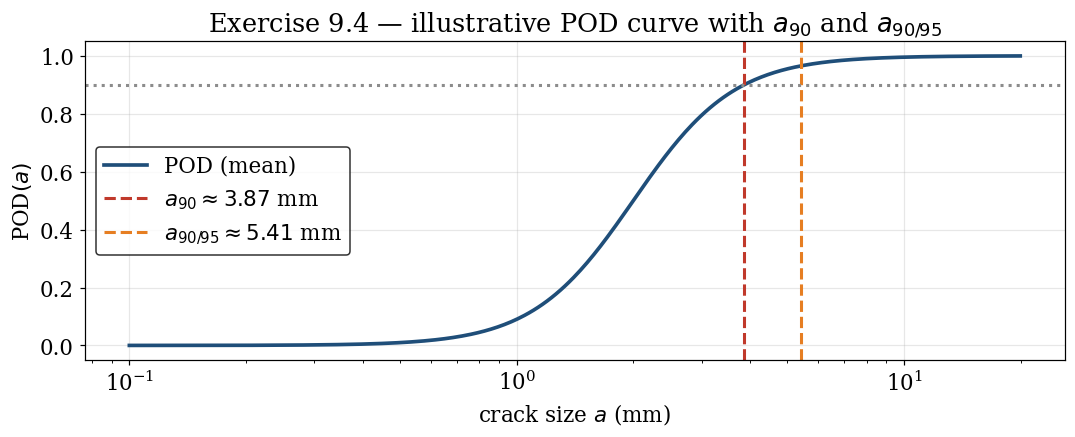

In [5]:
# Illustrate a generic POD curve (log-odds fit) and locate a_90/95
a_arr = np.logspace(-1, 1.3, 400)        # mm
# Log-odds POD: POD(a) = 1/(1 + exp(-(ln a - μ)/σ))
mu, sig = np.log(2.0), 0.30
POD = 1/(1 + np.exp(-(np.log(a_arr) - mu)/sig))
a_90  = float(np.exp(mu + sig*np.log(0.9/0.1)))
a_50  = float(np.exp(mu))
# 95% confidence: pseudo-shift mu_low = mu + 1.645*sig_std  (illustrative)
a_90_95 = a_90*1.4
fig, ax = plt.subplots()
ax.semilogx(a_arr, POD, color=COLORS['curve'], lw=2.4, label='POD (mean)')
ax.axvline(a_90, color=COLORS['point'], ls='--', label=fr'$a_{{90}}\approx{a_90:.2f}$ mm')
ax.axvline(a_90_95, color=COLORS['warn'], ls='--', label=fr'$a_{{90/95}}\approx{a_90_95:.2f}$ mm')
ax.axhline(0.9, color=COLORS['guide'], ls=':')
ax.set_xlabel(r'crack size $a$ (mm)'); ax.set_ylabel(r'POD$(a)$')
ax.set_title('Exercise 9.4 — illustrative POD curve with $a_{90}$ and $a_{90/95}$')
ax.legend(); plt.tight_layout(); plt.show()


#### Solution summary — Exercise 9.4

**(b) Weibull fit** (10 fatigue lives, median-rank estimator):

| Parameter | Value |
|---|---:|
| Shape $\beta$ | 2.355 |
| Scale $\eta$ | 100 200 cycles ($100.2 \times 10^3$) |
| $R^2$ (probability paper) | 0.880 |

$\beta > 1$ (wear-out regime) confirms that failures are concentrated in a finite-life band and the hazard rate increases with cycles — consistent with fatigue.
$\eta \approx 10^5$ cycles is the 63.2 % failure life.

**(c)–(d)** POD and $a_{90/95}$ are conceptual: no additional numerical results.

---

### Final remarks

* Scatter in fatigue is **dominated by the initiation period**, which makes
  it the hardest part of life to predict. Welded structures, with negligible
  initiation, are correspondingly less scattered.
* The Weibull distribution is the most-used model for fatigue life *after a
  defect exists*, and the **median-rank** plot is the standard graphical
  estimator.
* Damage-tolerant design rests on three quantitative legs: $\Delta K$,
  $K_{IC}$, and $a_{90/95}$. The third is statistical, not deterministic, and
  is the link between fracture mechanics and inspection planning.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.